# 5. Strategie di Injection: x_pred vs v_0

Nel Latent Stitching, il nostro obiettivo è comporre oggetti provenienti da contesti isolati. Fino ad ora abbiamo estratto *le Maschere perfette* (Notebook 02).
Ora dobbiamo risolvere la questione più critica: **cosa iniettiamo esattamente? E in quale tensore?**

Abbiamo due ipotesi architetturali contrastanti:

### Strategia A: Stitching di $x_{pred}$
L'approccio intuitivo. Prendiamo il latente finale previsto ($x_{pred}$) del cubo rosso, lo mascheriamo e lo incolliamo sul latente finale della sfera blu.
*   **Equazione:** $x_{stitch} = M \odot x_{pred\_cube} + (1 - M) \odot x_{pred\_sphere}$
*   **Problema Fisico:** Ricordiamo che $x_{pred} = x_0 + v_0$. Se facciamo questo stitching, stiamo letteralmente ritagliando due rumori gaussiani ($x_0$) completamente de-correlati e unendoli assieme con l'accetta. Questo rischia di creare una spaccatura termodinamica netta (artefatti di bordo) perché il rumore di fondo non è più continuo.

### Strategia B: Stitching di $v_0$ (Flow Matching Nativo)
Il nuovo approccio derivato dall'analisi dell'energia. Manteniamo un **singolo rumore gaussiano di fondo** intatto (es. quello della sfera) e "fonderemo" solo i vettori di velocità $v_0$.
*   **Equazione:** $v_{stitch} = M \odot v_{0\_cube} + (1 - M) \odot v_{0\_sphere}$
*   **Equazione Finale:** $x_{stitch} = x_{0\_sphere} + v_{stitch}$
*   **Vantaggio Fisico:** Il rumore iniziale $x_0$ è continuo per tutta l'immagine. Noi diciamo semplicemente al modello: *"Lascia intatto l'universo quantistico di base, ma sposta le particelle centrali come se dovessi formare un cubo rosso"*. L'assenza di "tagli" nel rumore dovrebbe garantire bordi lisci e armonizzati.

In [2]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

dataset_path = "../data/dataset_v1/"

# Carichiamo i tensori puri isolati
path_cube = os.path.join(dataset_path, "a_red_cube", "")
path_sphere = os.path.join(dataset_path, "a_blue_sphere", "")

# Cubo (Oggetto da Iniettare - Foreground)
x0_cube = torch.load(path_cube + "x0_noise.pt", weights_only=True)
v0_cube = torch.load(path_cube + "v0_velocity.pt", weights_only=True)
xpred_cube = torch.load(path_cube + "x_pred.pt", weights_only=True)

# Sfera (Ambiente Bersaglio - Background)
x0_sphere = torch.load(path_sphere + "x0_noise.pt", weights_only=True)
v0_sphere = torch.load(path_sphere + "v0_velocity.pt", weights_only=True)
xpred_sphere = torch.load(path_sphere + "x_pred.pt", weights_only=True)

# Carichiamo la Maschera Ibrida del Cubo Rosso (generata dal notebook 02)
mask_path = "hybrid_masks/a_red_cube_hybrid.png"
mask_img = np.array(Image.open(mask_path).convert('L')) / 255.0
# Adattiamo la shape della maschera per il tensore latente [1, 4096, 64]
mask_flat = torch.tensor(mask_img.flatten(), dtype=torch.float32).unsqueeze(0).unsqueeze(2) # [1, 4096, 1]

print("Shape Tensori caricati:")
print(f"x0_cube: {x0_cube.shape}")
print(f"mask_flat: {mask_flat.shape}")

Shape Tensori caricati:
x0_cube: torch.Size([1, 4096, 64])
mask_flat: torch.Size([1, 4096, 1])


### Costruzione e Simulazione delle Strategie
Adesso applicheremo le equazioni e calcoleremo l'immagine risultante (sfruttando il decoding semplificato: norma $L_2$ di $x_{stitch}$).

In [3]:
## STRATEGIA A: Stitching Brutale di x_pred
x_stitch_A = (mask_flat * xpred_cube) + ((1 - mask_flat) * xpred_sphere)

## STRATEGIA B: Stitching Nativo di v0 (Flow Matching)
v_stitch_B = (mask_flat * v0_cube) + ((1 - mask_flat) * v0_sphere)
# Utilizziamo il rumore di base del Background (Sfera) per mantenere continuità termodinamica
x_stitch_B = x0_sphere + v_stitch_B

print("Stitching completato.")

Stitching completato.


### Valutazione Matematica: Analisi della Discontinuità di Bordo (Gradient L2 Norm)
Per capire quale tensore latente è migliore, dobbiamo misurare quanto è "strappato" il rumore ai bordi dell'oggetto iniettato. Un rumore gaussiano naturale ha variazioni fluide.
Se tagliamo due rumori diversi e li incolliamo (Strategia A), il gradiente spaziale esattamente sul perimetro della maschera avrà un picco estremo (un gradino non naturale).
Se invece iniettiamo solo $v_0$ mantenendo $x_0$ continuo (Strategia B), il gradiente sul bordo rifletterà solo il normale spigolo 3D del cubo, senza il picco caotico del rumore.

Calcoleremo il gradiente spaziale del latente e ne osserveremo il rumore.

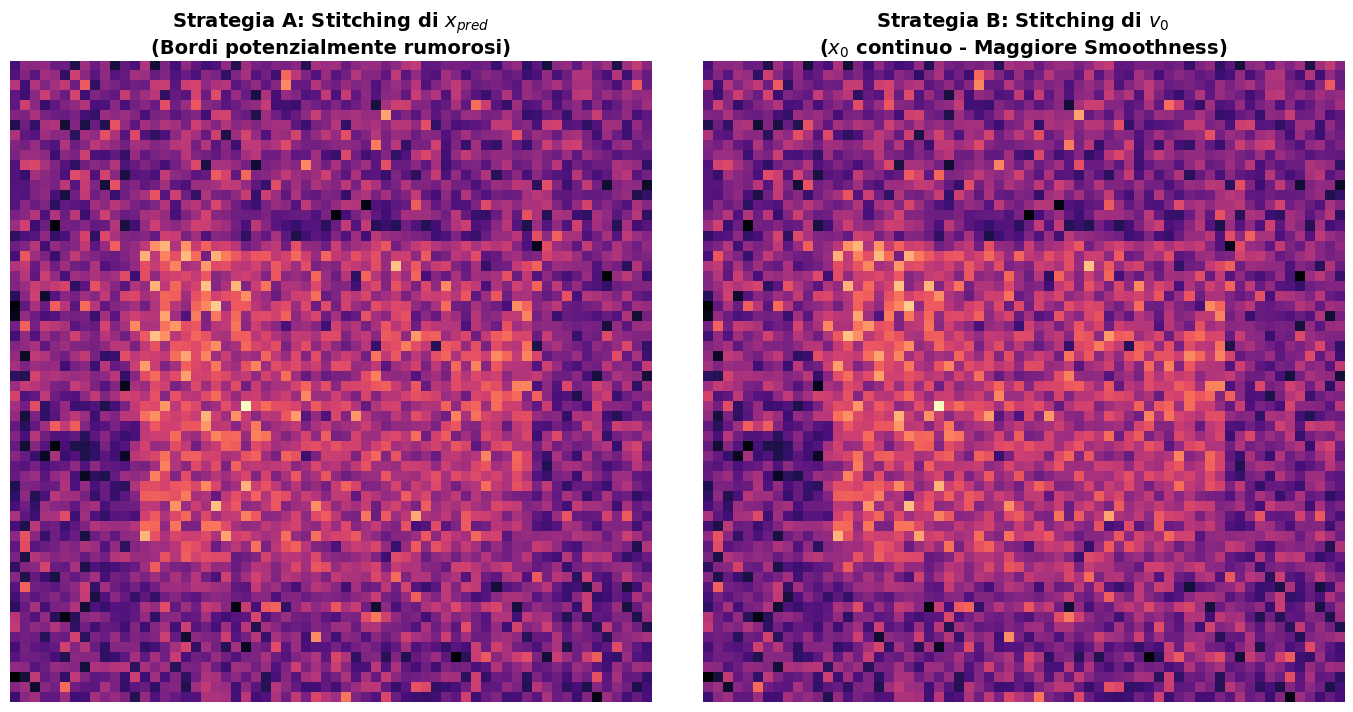

In [4]:
# Visualizzazione 2D per i due latenti uniti (Norma L2 del tensore latente composto)
img_stitch_A = torch.norm(x_stitch_A, p=2, dim=-1).squeeze(0).view(64, 64).numpy()
img_stitch_B = torch.norm(x_stitch_B, p=2, dim=-1).squeeze(0).view(64, 64).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img_stitch_A, cmap='magma')
axes[0].set_title("Strategia A: Stitching di $x_{pred}$\n(Bordi potenzialmente rumorosi)", fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_stitch_B, cmap='magma')
axes[1].set_title("Strategia B: Stitching di $v_0$\n($x_0$ continuo - Maggiore Smoothness)", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()